# Kernalized Support Vectore Machine

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import mglearn
from sklearn.model_selection import train_test_split
from mglearn.datasets import make_blobs

In [4]:
X, y = make_blobs(centers=4, random_state=8)
y = y % 2

Text(0, 0.5, 'Feature 1')

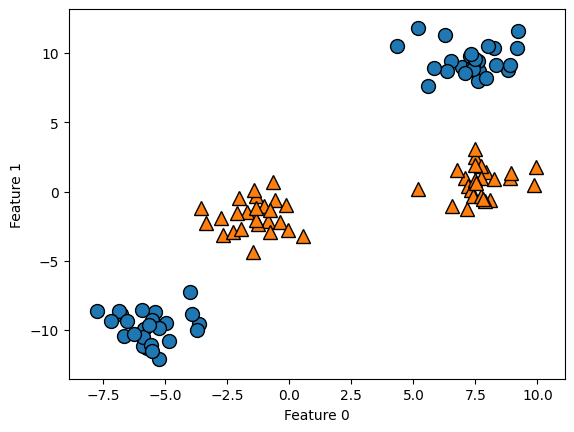

In [5]:
mglearn.discrete_scatter(X[:, 0], X[:,1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

In [6]:
from sklearn.svm import LinearSVC
linear = LinearSVC().fit(X, y)

Text(0, 0.5, 'Feature 1')

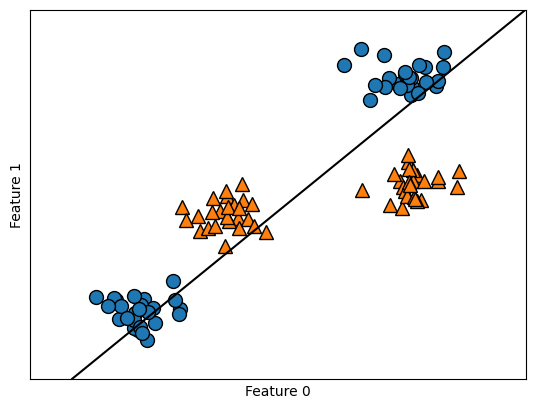

In [10]:
mglearn.plots.plot_2d_separator(linear, X)
mglearn.discrete_scatter(X[:,0], X[:,1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

In [13]:
from mpl_toolkits.mplot3d import Axes3D, axes3d

In [14]:
X_new = np.hstack([X, X[:, :1]**2])

In [18]:
figure = plt.Figure()
ax = Axes3D(figure, elev=-152, azim=-26)
mask = y == 0
ax.scatter(X_new[mask,0], X_new[mask, 1], X_new[mask, 2], c='b',cmap=mglearn.cm2, s=60)
ax.scatter(X_new[~mask,0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker="^",cmap=mglearn.cm2, s=60)
ax.set_xlabel("Feature 0")
ax.set_ylabel("Feature 1")
ax.set_zlabel("Feature1 ** 2")

C:\Users\qadri\AppData\Local\Temp\ipykernel_15524\4230751320.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_new[mask,0], X_new[mask, 1], X_new[mask, 2], c='b',cmap=mglearn.cm2, s=60)
C:\Users\qadri\AppData\Local\Temp\ipykernel_15524\4230751320.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_new[~mask,0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker="^",cmap=mglearn.cm2, s=60)


Text(0.5, 0, 'Feature1 ** 2')

In [ ]:
linear_svm_3d = LinearSVC().fit(X_new, y)
coef, intercept = linear_svm_3d.coef_.ravel(), linear_svm_3d.intercept_
# show linear decision boundary
figure = plt.figure()
ax = Axes3D(figure, elev=-152, azim=-26)
xx = np.linspace(X_new[:, 0].min() - 2, X_new[:, 0].max() + 2, 50)
yy = np.linspace(X_new[:, 1].min() - 2, X_new[:, 1].max() + 2, 50)
XX, YY = np.meshgrid(xx, yy)
ZZ = (coef[0] * XX + coef[1] * YY + intercept) / -coef[2]
ax.plot_surface(XX, YY, ZZ, rstride=8, cstride=8, alpha=0.3)
ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b',
 cmap=mglearn.cm2, s=60)
ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker='^',
 cmap=mglearn.cm2, s=60)
ax.set_xlabel("feature0")
ax.set_ylabel("feature1")
ax.set_zlabel("feature0 ** 2")

In [ ]:
from sklearn.svm import SVC
X, y = mglearn.tools.make_handcrafted_dataset()
svm = SVC(kernel='rbf', C=10, gamma=0.1).fit(X, y)
mglearn.plots.plot_2d_separator(svm, X, eps=.5)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
# plot support vectors
sv = svm.support_vectors_
# class labels of support vectors are given by the sign of the dual coefficients
sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:, 0], sv[:, 1], sv_labels, s=15, markeredgewidth=3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

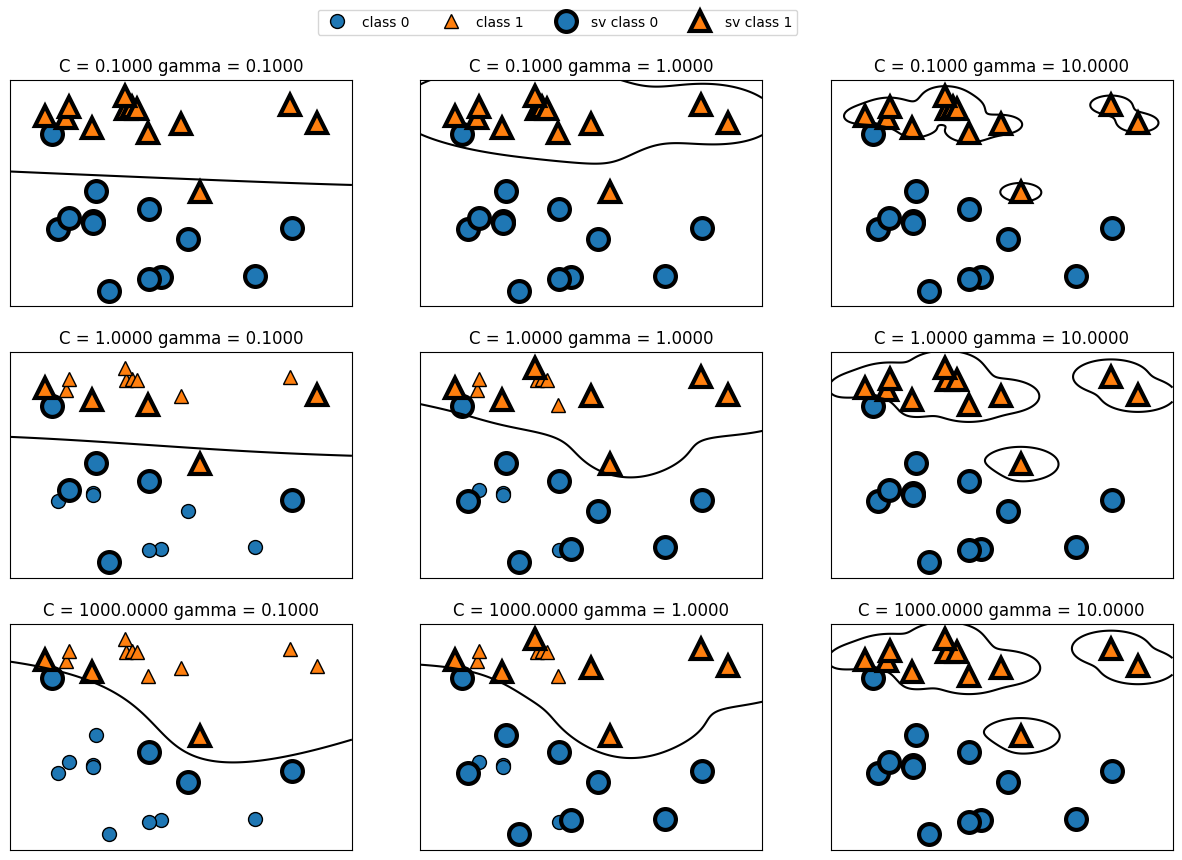

In [2]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, C in zip(axes, [-1, 0, 3]):
    for a, gamma in zip(ax, range(-1, 2)):
        mglearn.plots.plot_svm(log_C=C, log_gamma=gamma, ax=a)
axes[0, 0].legend(["class 0", "class 1", "sv class 0", "sv class 1"],
 ncol=4, loc=(.9, 1.2))